# Module 14: Logistic Regression

Sections:
- 0: Setup
- 1: Introduction to Logistic Regression (toy example)
- 2: Sigmoid Function and Classification Intuition
- 3: Logistic Regression on a Real Dataset
- 4: Evaluation Metrics and Threshold Effects
- 5: L2 Regularization
- 6: Conclusion and Next Steps

## Section 0 – Setup

In this section we will:
- Import required libraries
- Set a random seed for reproducibility
- A short outline for students to follow the flow.

In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

from sklearn.datasets import load_breast_cancer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)
from sklearn.preprocessing import StandardScaler

## Section 1 – Introduction to Logistic Regression (toy example)

Goal:
- A very simple feel of what logistic regression does before we dive into math.

We will create a tiny toy dataset:
- Feature: `hours_studied`
- Target: `pass_exam` (0 or 1)

Then we will:
- Fit a logistic regression model in sklearn
- Predict pass or fail for a few sample students
- Plot the points and the model prediction curve.

Outcome:
- Linear regression predicts a continuous number
- Logistic regression predicts a probability between 0 and 1.


In [3]:
# Create a simple toy dataset
hours_studied = np.array([1, 2, 3, 4, 5, 6, 7, 8, 9]).reshape(-1, 1)
pass_exam = np.array([0, 0, 0, 0, 1, 1, 1, 1, 1])

toy_df = pd.DataFrame({
    "hours_studied": hours_studied.flatten(),
    "pass_exam": pass_exam
})

toy_df

,hours_studied,pass_exam
0,1,0
1,2,0
2,3,0
3,4,0
4,5,1
5,6,1
6,7,1
7,8,1
8,9,1


In [4]:
# Fit logistic regression on the toy dataset
toy_model = LogisticRegression()
toy_model.fit(hours_studied, pass_exam)

print("Intercept (b):", toy_model.intercept_)
print("Coefficient (w):", toy_model.coef_)

Intercept (b): [-5.29559243]
Coefficient (w): [[1.17808562]]


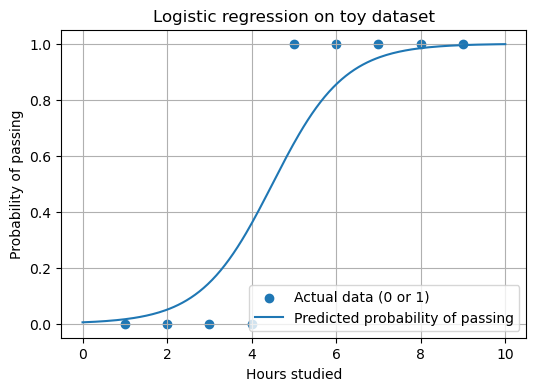

In [5]:
# Predict probabilities for a range of study hours
hours_grid = np.linspace(0, 10, 200).reshape(-1, 1)
pass_prob = toy_model.predict_proba(hours_grid)[:, 1]

# Plot data points and probability curve
plt.figure(figsize=(6, 4))
plt.scatter(hours_studied, pass_exam, label="Actual data (0 or 1)")
plt.plot(hours_grid, pass_prob, label="Predicted probability of passing")
plt.xlabel("Hours studied")
plt.ylabel("Probability of passing")
plt.title("Logistic regression on toy dataset")
plt.legend()
plt.grid(True)
plt.show()

In [6]:
# Predict for a few example students
example_hours = np.array([[2], [4], [6], [8]])
example_probs = toy_model.predict_proba(example_hours)[:, 1]
example_pred = toy_model.predict(example_hours)

results_df = pd.DataFrame({
    "hours_Studied": example_hours.flatten(),
    "Predicted_probability_pass": np.round(example_probs, 4),
    "Predicted_class": example_pred
})

results_df

,hours_Studied,Predicted_probability_pass,Predicted_class
0,2,0.0502,0
1,4,0.3582,0
2,6,0.8548,1
3,8,0.9842,1


**Notes:**

- Ekhane model bole je beshi porle pass korar chance barbe.  
- Logistic regression is giving a probability, not a raw pass or fail. The predicted class comes after applying a threshold like 0.5.
